# 04 - Assumptions, validation, and leakage checks

A Cox model can look professional while being wrong. This notebook teaches the checks that stop that from happening.

We will look at:

- Held-out concordance, and what the C-index actually measures.
- Proportional-hazards diagnostics, plus one demonstrated remedy when a covariate fails them.
- Horizon calibration done two ways: the tempting biased way and the censoring-aware way.
- Two deliberate leakage examples: the textbook kind and the subtle kind that actually ships.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Targeted filters only: pandas deprecation chatter fired from inside lifelines'
# stratified fit, and a benign index notice from lifelines scoring. Everything
# else -- convergence warnings included -- stays visible on purpose.
warnings.filterwarnings("ignore", message="The default of observed=False is deprecated")
warnings.filterwarnings("ignore", message="DataFrame Index is not unique")

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

## The headline metric, defined

Every check below leans on the concordance index, so let's define it once. Take every comparable pair of customers. If the model assigns the higher risk to the customer who actually left sooner, the pair is a success. The C-index is the fraction of successes: 0.5 is a coin flip, 1.0 is a perfect ranking.

Censoring shrinks the set of comparable pairs. If the shorter time in a pair is censored, we never learn who left first, so the pair is unusable. About 51% of this dataset is censored, and with that much censoring plain Harrell's C can flatter the model, because the pairs we can grade are not a random sample of the pairs we care about. The standard fix is the IPCW C-index (Uno's C), which reweights the gradable pairs; the pipelines in the main repo (`scripts/01_survival.py`, `dunnhumby/scripts/06_customer_survival_analysis.py`) use it throughout. Here we stay with Harrell's C to keep the lifelines workflow simple, knowing it screens rather than certifies.

Two modelling choices, stated so you don't have to guess:

- The split is stratified on the event indicator so train and test carry the same event rate; with half the rows censored, an unlucky split would change how many gradable pairs each side gets.
- No penalizer. The training set has 593 events for 11 covariates, roughly 54 events per variable, so there is no small-sample case for shrinkage, and an unjustified ridge penalty only biases hazard ratios toward 1. (Notebook 03 makes the same call.)

In [2]:
from sklearn.model_selection import train_test_split
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
from lifelines.utils import concordance_index

churn = pd.read_csv(DATA_DIR / "service_churn_drivers.csv")
model_df = pd.get_dummies(
    churn.drop(columns=["customer_id"]),
    columns=["plan", "industry"],
    drop_first=True,
)

train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    random_state=7,
    stratify=model_df["churn_observed"],
)

cph = CoxPHFitter()
cph.fit(train_df, duration_col="duration_days", event_col="churn_observed")

print("Training events:", int(train_df["churn_observed"].sum()), "for", train_df.shape[1] - 2, "covariates")
print("Train concordance:", round(cph.concordance_index_, 3))
print("Test concordance:", round(cph.score(test_df, scoring_method="concordance_index"), 3))

# A point estimate deserves an error bar: bootstrap the test set.
rng = np.random.default_rng(7)
risk = cph.predict_partial_hazard(test_df).to_numpy()
dur = test_df["duration_days"].to_numpy()
event = test_df["churn_observed"].to_numpy()
boot = [
    concordance_index(dur[idx], -risk[idx], event[idx])
    for idx in (rng.integers(0, len(dur), len(dur)) for _ in range(500))
]
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Test concordance 95% bootstrap CI (500 resamples): [{lo:.3f}, {hi:.3f}]")

Training events: 593 for 11 covariates
Train concordance: 0.721
Test concordance: 0.709


Test concordance 95% bootstrap CI (500 resamples): [0.672, 0.748]


## Check 1: proportional hazards

The Cox model assumes a feature has a roughly constant multiplicative effect over time.

Example:

> If training completion reduces churn hazard by 30%, that ratio is roughly similar early and late in the timeline.

The diagnostic below is a screen, not a courtroom verdict. Small p-values mean "look closer." Two honesty notes before reading it:

- This is 11 simultaneous tests. Under a true null you would expect one p-value near 0.09 by luck alone, so a single small p is a screen-level signal, not a discovery.
- The test depends on how time is transformed, and the transforms can disagree: discount_pct comes out at p = 0.005 under "km", 0.009 under "rank", and 0.056 under "log".

In [3]:
ph = proportional_hazard_test(cph, train_df, time_transform="rank")
ph.summary.sort_values("p").round(4)  # all 11 covariates, nothing hidden

,test_statistic,p,-log2(p)
discount_pct,6.9306,0.0085,6.8828
login_days_30,2.7676,0.0962,3.3780
support_tickets_30,0.9415,0.3319,1.5912
monthly_fee,0.9311,0.3346,1.5796
seats,0.7575,0.3841,1.3804
plan_Pro,0.5047,0.4774,1.0666
training_completed,0.4109,0.5215,0.9392
industry_Retail,0.3650,0.5457,0.8737
plan_Enterprise,0.2999,0.5840,0.7761
industry_SaaS,0.1284,0.7201,0.4738


## Closing the loop on discount_pct

Only one covariate is flagged, so we do not get to walk away. We promised "look closer" -- here is what that looks like.

First, what a violation would mean. If the discount effect changes over time, the single fitted hazard ratio (0.96 per discount point) is not wrong so much as compressed: it is roughly a time-weighted average of a time-varying effect, weighted toward the periods with the most events. That average is still a usable summary for ranking customers, but quoting it as "the" effect hides the time pattern.

The plot below shows the scaled Schoenfeld residuals for discount_pct against transformed time. Under proportional hazards the smoothed curve should hover around a horizontal line; a drift is the violation.


   Bootstrapping lowess lines. May take a moment...





1. Variable 'discount_pct' failed the non-proportional test: p-value is 0.0052.



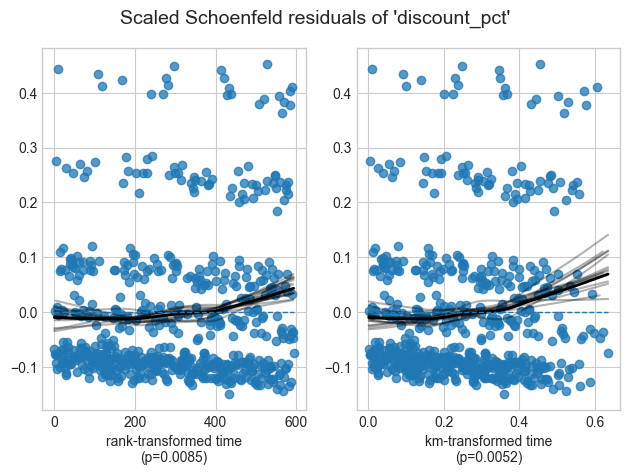

In [4]:
_ = cph.check_assumptions(
    train_df,
    columns=["discount_pct"],
    p_value_threshold=0.05,
    show_plots=True,
    advice=False,
)

The smoothed curve drifts upward: the discount coefficient starts clearly negative (protective) and fades toward zero later in the timeline. Discounts seem to delay churn early on, and the protection wears off. That is a believable retention story, and it is exactly the pattern a single hazard ratio averages away.

One demonstrated remedy: stratification. Bin discount_pct and pass the bin to `strata=`. The model then fits a separate baseline hazard per stratum, so discount's time pattern no longer has to squeeze into one proportional coefficient. The price is honest: a stratification variable has no hazard ratio anymore -- it is absorbed into the baselines -- so stratify on a covariate you want to adjust for, not one you need to quote. Other remedies worth knowing by name: time-varying coefficients (interact the covariate with a function of time), or splitting the time axis into episodes and fitting each separately.

One wrinkle: discount_pct only takes the values 0, 5, 10, 20 and 30, so clean terciles do not exist. We bin on the natural business boundaries instead: no discount, up to 10%, above 10%.

In [5]:
def add_discount_band(df):
    banded = df.copy()
    banded["discount_band"] = pd.cut(
        banded["discount_pct"], bins=[-1, 0, 10, 30], labels=["none", "low", "deep"]
    )
    return banded.drop(columns=["discount_pct"])

strat_train = add_discount_band(train_df)
print(strat_train["discount_band"].value_counts().to_string())

cph_strata = CoxPHFitter()
cph_strata.fit(
    strat_train,
    duration_col="duration_days",
    event_col="churn_observed",
    strata=["discount_band"],
)

ph_after = proportional_hazard_test(cph_strata, strat_train, time_transform="rank")
print("Smallest remaining PH p-value:", round(ph_after.summary["p"].min(), 3))

pd.DataFrame({
    "HR_pooled": cph.hazard_ratios_.drop("discount_pct"),
    "HR_stratified": cph_strata.hazard_ratios_,
}).round(3)

discount_band
none    538
low     424
deep    238
Smallest remaining PH p-value: 0.239


,HR_pooled,HR_stratified
covariate,,
seats,0.977,0.980
monthly_fee,1.002,1.002
login_days_30,0.954,0.956
support_tickets_30,1.251,1.253
training_completed,0.600,0.601
plan_Enterprise,0.295,0.302
plan_Pro,0.517,0.522
industry_Manufacturing,0.909,0.899
industry_Retail,1.104,1.110


The other covariates barely move -- the largest hazard-ratio shift is about 0.01 -- which is what you want to see: fixing the discount problem did not destabilize the rest of the story. And with discount absorbed into the baselines, nothing is flagged anymore (smallest remaining p is about 0.24).

## Check 2: calibration at a business horizon

Concordance checks ranking. A business often also asks:

> If we say a group has 30% churn risk by day 180, does about 30% churn by day 180?

There is a tempting way to answer and a correct way, and the gap between them is censoring.

The tempting way: within each predicted-risk decile, drop everyone censored before day 180 (we cannot label them) and take a plain churn rate on the rest. This is complete-case analysis, and it is biased upward. A customer who churned at day 120 passes the filter; a customer censored at day 120 does not. Short event times survive the filter more easily than short censored times, so the kept sample is churn-enriched.

The correct way: fit a small Kaplan-Meier curve on all rows of the decile and read off 1 - S(180). Censored customers then contribute exactly the risk time they were observed for, and nobody is thrown away.

The table shows both, side by side, on the same deciles.

In [6]:
horizon = 180
X_test = test_df.drop(columns=["duration_days", "churn_observed"])

cal = test_df[["duration_days", "churn_observed"]].copy()
cal["predicted_churn_by_180d"] = (
    1 - cph.predict_survival_function(X_test, times=[horizon]).T[horizon]
).to_numpy()
cal["risk_decile"] = pd.qcut(cal["predicted_churn_by_180d"], q=10, labels=False, duplicates="drop") + 1

n_censored_early = int(((cal["duration_days"] < horizon) & cal["churn_observed"].eq(0)).sum())
print("Test customers censored before day 180 (silently dropped by the tempting approach):", n_censored_early)

rows = []
for decile, grp in cal.groupby("risk_decile"):
    # Tempting but biased: complete-case rate after dropping the early-censored.
    knowable = grp[(grp["duration_days"] >= horizon) | grp["churn_observed"].eq(1)]
    complete_case = (knowable["churn_observed"].eq(1) & (knowable["duration_days"] <= horizon)).mean()
    # Correct: Kaplan-Meier on every row of the decile.
    km = KaplanMeierFitter().fit(grp["duration_days"], grp["churn_observed"])
    rows.append({
        "decile": decile,
        "n": len(grp),
        "n_after_drop": len(knowable),
        "predicted": grp["predicted_churn_by_180d"].mean(),
        "observed_complete_case": complete_case,
        "observed_km": 1 - km.predict(horizon),
    })
cal_table = pd.DataFrame(rows)

print("Complete-case minus KM, averaged over deciles:",
      round((cal_table["observed_complete_case"] - cal_table["observed_km"]).mean(), 3))
print("Mean |predicted - KM observed|:",
      round((cal_table["predicted"] - cal_table["observed_km"]).abs().mean(), 3))
cal_table.round(3)

Test customers censored before day 180 (silently dropped by the tempting approach): 31
Complete-case minus KM, averaged over deciles: 0.024
Mean |predicted - KM observed|: 0.036


,decile,n,n_after_drop,predicted,observed_complete_case,observed_km
0,1,40,39,0.102,0.077,0.075
1,2,40,34,0.161,0.206,0.175
2,3,40,34,0.206,0.206,0.175
3,4,40,37,0.252,0.324,0.306
4,5,40,35,0.314,0.343,0.303
5,6,40,37,0.414,0.405,0.381
6,7,40,37,0.506,0.459,0.429
7,8,40,39,0.595,0.538,0.528
8,9,40,38,0.700,0.711,0.679
9,10,40,39,0.830,0.872,0.850


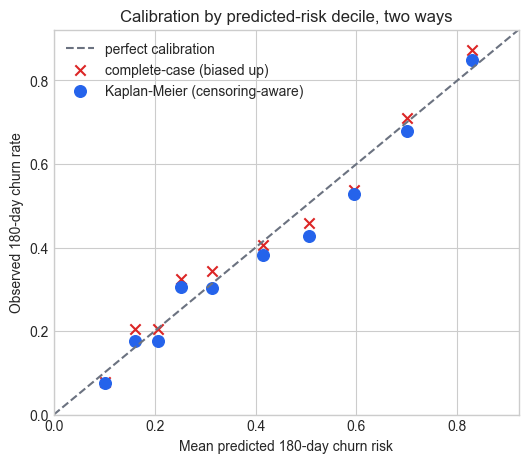

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="#6B7280", label="perfect calibration")
ax.scatter(
    cal_table["predicted"], cal_table["observed_complete_case"],
    s=55, marker="x", color="#DC2626", label="complete-case (biased up)",
)
ax.scatter(
    cal_table["predicted"], cal_table["observed_km"],
    s=70, color="#2563EB", label="Kaplan-Meier (censoring-aware)",
)
upper = float(
    max(cal_table["predicted"].max(), cal_table["observed_complete_case"].max(), cal_table["observed_km"].max())
) + 0.05
ax.set_xlim(0, upper)
ax.set_ylim(0, upper)
ax.set_xlabel("Mean predicted 180-day churn risk")
ax.set_ylabel("Observed 180-day churn rate")
ax.set_title("Calibration by predicted-risk decile, two ways")
ax.legend()
plt.show()

Reading it:

- The complete-case column sits above the KM column in almost every decile, about +0.02 on average; decile 5, for example, reads 0.343 complete-case but 0.303 once censoring is handled. That is the direction the bias story predicts: dropping the early-censored inflates observed churn.
- Do not over-read the scatter. With roughly 40 customers per decile, a true rate near 0.5 carries a binomial standard error of about 0.08, so wobbles of that size are noise.
- The summary number: the mean absolute gap between predicted risk and KM-observed churn is about 0.036. For a screening model that is decent calibration; for pricing decisions you would want it tighter, and more data behind each bin.

## Check 3: leakage

Leakage means a feature knows something from after the prediction moment.

It comes in two strengths. The textbook kind -- a feature manufactured from the label itself -- is rare in practice, because nobody writes it on purpose. The kind that actually ships is subtler: an innocent-looking feature whose computation window is anchored at the end of the study instead of at the prediction time. The repo's field guide (`LESSONS_LEARNED.md`, section 1) calls that the sneakiest form for a reason. We will build both and watch the test metric.

First, the textbook kind. The flag below literally records whether the customer survived past day 180 -- knowledge from the future, named honestly.

In [8]:
def held_out_concordance(df, label):
    """Split, fit, score -- and surface any fit warnings instead of hiding them."""
    tr, te = train_test_split(df, test_size=0.25, random_state=7, stratify=df["churn_observed"])
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model = CoxPHFitter().fit(tr, duration_col="duration_days", event_col="churn_observed")
    for w in caught:
        print(f"[{label}] {w.category.__name__}: {str(w.message).strip().splitlines()[0]}")
    return model.score(te, scoring_method="concordance_index")

clean_c = held_out_concordance(model_df, "clean")

textbook_df = model_df.copy()
textbook_df["future_knows_survived_past_180d"] = (textbook_df["duration_days"] > 180).astype(int)
textbook_c = held_out_concordance(textbook_df, "textbook leak")

print()
print("Clean test concordance:        ", round(clean_c, 3))
print("Textbook-leak test concordance:", round(textbook_c, 3))

[textbook leak] ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.500. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

Clean test concordance:         0.709
Textbook-leak test concordance: 0.849


The forbidden flag jumps the test C-index from 0.709 to 0.849, and lifelines even mutters about it: that convergence warning is the sound of one feature explaining the outcome almost by itself. Complete-separation and convergence warnings on a newly added feature are a leakage tripwire. Read them; do not suppress them.

Nobody builds that flag by accident. Here is the version people do build by accident.

Suppose the study window ends at day 365, and censored customers are the ones still active when it closed. Then:

- `active_in_last_30d_of_study`: did the customer have any activity in the study's final 30 days? For a censored customer that is simply `duration_days >= 335`. It sounds like a harmless recency feature. It is anchored at the study end, not at the prediction time.
- `days_inactive_at_study_end`: how long has the customer been idle, measured at the study end? Zero for the still-active, `365 - duration_days` for churners. This is the classic recency feature, computed in the one place recency must never be computed.

In [9]:
STUDY_END = 365

subtle_mild = model_df.copy()
subtle_mild["active_in_last_30d_of_study"] = (
    (subtle_mild["duration_days"] >= STUDY_END - 30) & subtle_mild["churn_observed"].eq(0)
).astype(int)
mild_c = held_out_concordance(subtle_mild, "subtle leak, mild")

subtle_recency = model_df.copy()
subtle_recency["days_inactive_at_study_end"] = np.where(
    subtle_recency["churn_observed"].eq(1),
    STUDY_END - subtle_recency["duration_days"],
    0,
)
recency_c = held_out_concordance(subtle_recency, "subtle leak, recency")

print()
pd.DataFrame({
    "model": [
        "clean features only",
        "textbook: survived_past_180d",
        "subtle: active_in_last_30d_of_study",
        "subtle: days_inactive_at_study_end",
    ],
    "test_concordance": [clean_c, textbook_c, mild_c, recency_c],
}).round(3)

[subtle leak, mild] ConvergenceWarning: Column active_in_last_30d_of_study have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:
[subtle leak, mild] ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.221. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?
[subtle leak, recency] ConvergenceWarning: Column days_inactive_at_study_end have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:
[subtle leak, recency] ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-

,model,test_concordance
0,clean features only,0.709
1,textbook: survived_past_180d,0.849
2,subtle: active_in_last_30d_of_study,0.725
3,subtle: days_inactive_at_study_end,1.000


What to take from the table:

- The mild flavor only nudges the metric, 0.709 to 0.725. That is the scary part: shipped inside a feature-engineering batch, it would read as a genuine small win, and nobody would ask questions.
- Give the same study-end anchor a richer shape -- continuous recency instead of a binary flag -- and the C-index saturates at 1.000. This is the field guide's "too-good-to-be-true C-index" failure, reproduced on demand.
- Neither feature mentions the label. Both encode it anyway, because any feature whose window is anchored at the study end is a function of the outcome.

The audit rule is one question, asked of every feature: **would I have known this value at the prediction time?** If the honest answer involves the study end, the answer is no. The field guide's mitigation is the landmark design -- pick a time t0 in the past and build features strictly from data on or before t0 -- which is how the main repo's pipelines are built.

## A practical review checklist

Before trusting a survival model, ask:

- Was time zero defined before all predictors?
- For every feature: would we have known its value at the prediction moment, or is its window anchored at the study end?
- Were censored rows treated as censored, not as permanent non-events?
- Are train/test splits done by entity and, when relevant, by time?
- Are early-stopping, tuning, and threshold choices made without looking at the test set?
- Do the survival probabilities decrease over time?
- Are predictions stated as conditional on being at risk at the prediction moment?
- Did we check proportional hazards or choose a model that does not need that assumption?

This is the difference between a demo and work you can defend.